In [1]:
# =============================================================================
# PASO 1: PREPROCESAMIENTO DE DATOS
# =============================================================================
# Importamos nuestra clase de preprocesamiento que encapsula:
#   - Tratamiento de nulls (eliminar, imputar por mediana/moda, marcar como desconocido)
#   - Encoding de variables categoricas (OneHotEncoder para baja cardinalidad)
#   - Encoding de texto libre (TextEncoder con modelo e5-small-v2)
#   - Transformacion de variables numericas (QuantileTransformer -> distribucion normal)
#   - Creacion de features polinomicas (interacciones degree=2 solo entre numericas)
#
# El fichero Excel contiene la lista de variables candidatas a ser predictoras.

from src.preprocessing.base_preprocessing import BasePreprocess

base_pre = BasePreprocess("data/variables_withoutExperts.xlsx", "loan_status")

In [2]:
# fit(): aprende los parametros del preprocesamiento con los datos de entrenamiento.
# Esto incluye: categorias del OHE, medianas para imputacion, parametros del QuantileTransformer, etc.
# IMPORTANTE: solo se hace fit en train para evitar data leakage.

base_pre.fit("data/df_train_small.csv")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:62: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.train_X_data['earliest_cr_line'] = pd.to_datetime(self.train_X_data['earliest_cr_line'])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# transform(): aplica las transformaciones aprendidas en fit() a los datos de entrenamiento.
# Devuelve X_data (features) e y_data (target binarizado: True = default, False = fully paid).

X_data, y_data = base_pre.transform("data/df_train_small.csv")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


In [4]:
# Verificamos las dimensiones tras el preprocesamiento.
# Las features polinomicas (interacciones entre numericas) incrementan el numero de columnas.
print(f"Dimensiones tras preprocesamiento: {X_data.shape[0]} filas x {X_data.shape[1]} columnas")

Dimensiones tras preprocesamiento: 80000 filas x 2614 columnas


In [5]:
# =============================================================================
# PASO 2: SELECCION DE FEATURES - Eliminacion de features constantes / cuasi-constantes
# =============================================================================
# DropConstantFeatures elimina columnas cuyo valor es el mismo (o casi) en todas las filas.
# Con tol=0.9, eliminamos features donde el 90% o mas de los valores son identicos.
# Estas features no aportan informacion discriminante al modelo.

from feature_engine.selection import DropConstantFeatures

transformer = DropConstantFeatures(tol=0.9)
transformer.fit(X_data)

,variables,None
,tol,0.9
,missing_values,'raise'
,confirm_variables,False


In [6]:
X_data_not_constant = transformer.transform(X_data)

n_dropped = X_data.shape[1] - X_data_not_constant.shape[1]
print(f"Features eliminadas por ser constantes/cuasi-constantes: {n_dropped}")
print(f"Features restantes: {X_data_not_constant.shape[1]}")

Features eliminadas por ser constantes/cuasi-constantes: 133
Features restantes: 2481


In [7]:
# =============================================================================
# PASO 3: SELECCION DE FEATURES - Eliminacion de features correlacionadas
# =============================================================================
# DropCorrelatedFeatures elimina una de cada par de features con correlacion > threshold.
# Cuando dos features estan muy correladas (> 0.8), aportan informacion redundante.
# Eliminar una de ellas reduce dimensionalidad sin perder capacidad predictiva,
# y mejora la estabilidad e interpretabilidad del modelo.

from feature_engine.selection import DropCorrelatedFeatures

tr = DropCorrelatedFeatures(variables=None, method='pearson', threshold=0.8)

In [8]:
tr.fit(X_data_not_constant, y_data)
print(f"Grupos de features correlacionadas encontrados: {len(tr.correlated_feature_sets_)}")

Grupos de features correlacionadas encontrados: 346


In [9]:
X_filtered = tr.transform(X_data_not_constant)

n_dropped = X_data_not_constant.shape[1] - X_filtered.shape[1]
print(f"Features eliminadas por alta correlacion: {n_dropped}")
print(f"Features restantes: {X_filtered.shape[1]}")

Features eliminadas por alta correlacion: 1839
Features restantes: 642


In [10]:
# Veamos los grupos de features correlacionadas.
# Cada conjunto muestra features que estan correlacionadas entre si (> 0.8).
# De cada grupo, se elimina todas menos una.
tr.correlated_feature_sets_

[{'acc_now_delinq acc_open_past_24mths',
  'acc_open_past_24mths',
  'acc_open_past_24mths chargeoff_within_12_mths',
  'acc_open_past_24mths delinq_amnt',
  'acc_open_past_24mths mths_since_recent_bc_dlq',
  'acc_open_past_24mths mths_since_recent_revol_delinq',
  'acc_open_past_24mths num_accts_ever_120_pd',
  'acc_open_past_24mths num_tl_120dpd_2m',
  'acc_open_past_24mths num_tl_30dpd',
  'acc_open_past_24mths num_tl_90g_dpd_24m',
  'acc_open_past_24mths pub_rec_bankruptcies',
  'acc_open_past_24mths tax_liens',
  'collections_12_mths_ex_med acc_open_past_24mths',
  'delinq_2yrs acc_open_past_24mths',
  'il_util acc_open_past_24mths',
  'inq_fi acc_open_past_24mths',
  'inq_last_12m acc_open_past_24mths',
  'mths_since_last_major_derog acc_open_past_24mths',
  'mths_since_last_record acc_open_past_24mths',
  'open_acc_6m acc_open_past_24mths',
  'open_act_il acc_open_past_24mths',
  'open_il_12m acc_open_past_24mths',
  'open_il_24m acc_open_past_24mths',
  'open_rv_12m acc_open_pa

In [11]:
# =============================================================================
# PASO 4: SELECCION DE FEATURES - ProbeFeatureSelection
# =============================================================================
# ProbeFeatureSelection es una tecnica inteligente para eliminar features irrelevantes:
#
# 1. Genera N features aleatorias ("probes") con distribucion normal.
# 2. Entrena un modelo (RandomForest) con todas las features reales + las probes.
# 3. Calcula la importancia de cada feature.
# 4. Elimina las features reales cuya importancia sea MENOR que la de las probes.
#
# Logica: si una feature real no es mas importante que ruido aleatorio,
# no aporta informacion util al modelo.
#
# Ventaja vs RFE (Recursive Feature Elimination):
#   - RFE elimina features una a una, re-entrenando el modelo en cada iteracion.
#     Con 600 features y cv=3, son ~1800 entrenamientos -> MUY LENTO.
#   - ProbeFeatureSelection solo necesita un entrenamiento con CV -> MUCHO MAS RAPIDO.
#
# Parametros relajados para conservar mas features:
#   - n_probes=10: con mas probes el umbral de importancia es mas estable y justo.
#     Con pocas probes (3), una probe puede tener por azar importancia alta y eliminar
#     features utiles. Con 10 probes, el umbral se estabiliza.
#   - max_depth=10: limita la profundidad de los arboles para que el estimador no
#     "memorice" y de importancia artificial a las probes.

from feature_engine.selection import ProbeFeatureSelection
from sklearn.ensemble import RandomForestClassifier

sel = ProbeFeatureSelection(
    estimator=RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    variables=None,
    scoring="roc_auc",
    n_probes=10,
    distribution="normal",
    cv=3,
    random_state=150,
    confirm_variables=False
)

In [12]:
sel.fit(X_filtered, y_data)

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestC...ndom_state=42)
,variables,None
,collective,True
,scoring,'roc_auc'
,n_probes,10
,distribution,'normal'
,n_categories,10
,threshold,'mean'
,cv,3
,groups,None
,random_state,150


In [13]:
X_filtered_2 = sel.transform(X_filtered)

n_dropped = X_filtered.shape[1] - X_filtered_2.shape[1]
print(f"Features eliminadas por ser peores que ruido aleatorio: {n_dropped}")
print(f"Features seleccionadas finales: {X_filtered_2.shape[1]}")
print(f"\nFeatures seleccionadas:")
print(X_filtered_2.columns.tolist())

Features eliminadas por ser peores que ruido aleatorio: 429
Features seleccionadas finales: 213

Features seleccionadas:
['verification_status_Not Verified', 'verification_status_Verified', 'term_ 36 months', 'emp_title_00', 'emp_title_01', 'emp_title_02', 'emp_title_03', 'emp_title_04', 'emp_title_08', 'emp_title_10', 'emp_title_14', 'emp_title_19', 'loan_amnt', 'annual_inc', 'dti', 'loan_amnt annual_inc', 'loan_amnt dti', 'loan_amnt inq_last_6mths', 'loan_amnt mths_since_last_delinq', 'loan_amnt open_acc', 'loan_amnt revol_bal', 'loan_amnt revol_util', 'loan_amnt all_util', 'loan_amnt total_rev_hi_lim', 'loan_amnt acc_open_past_24mths', 'loan_amnt avg_cur_bal', 'loan_amnt bc_open_to_buy', 'loan_amnt bc_util', 'loan_amnt mo_sin_rcnt_rev_tl_op', 'loan_amnt mo_sin_rcnt_tl', 'loan_amnt mort_acc', 'loan_amnt mths_since_recent_bc', 'loan_amnt mths_since_recent_inq', 'loan_amnt num_actv_rev_tl', 'loan_amnt num_tl_op_past_12m', 'loan_amnt percent_bc_gt_75', 'loan_amnt total_bal_ex_mort', 'lo

In [14]:
# =============================================================================
# Resumen del pipeline de seleccion de features
# =============================================================================
print("=" * 60)
print("RESUMEN DEL PIPELINE DE SELECCION DE FEATURES")
print("=" * 60)
print(f"  Tras preprocesamiento:           {X_data.shape[1]} features")
print(f"  Tras eliminar cuasi-constantes:  {X_data_not_constant.shape[1]} features")
print(f"  Tras eliminar correlacionadas:   {X_filtered.shape[1]} features")
print(f"  Tras ProbeFeatureSelection:      {X_filtered_2.shape[1]} features")
print("=" * 60)

RESUMEN DEL PIPELINE DE SELECCION DE FEATURES
  Tras preprocesamiento:           2614 features
  Tras eliminar cuasi-constantes:  2481 features
  Tras eliminar correlacionadas:   642 features
  Tras ProbeFeatureSelection:      213 features


In [15]:
# =============================================================================
# PASO 5: ENTRENAMIENTO DEL MODELO - Random Forest
# =============================================================================
# Random Forest es un ensemble de arboles de decision:
#   - Entrena N arboles (n_estimators) sobre submuestras aleatorias de datos y features.
#   - La prediccion final es la votacion mayoritaria (clasificacion) o media (regresion).
#   - Ventajas: robusto al overfitting, maneja no-linealidades, da importancia de features.
#   - n_jobs=-1 usa todos los cores del procesador para paralelizar el entrenamiento.
#
# class_weight='balanced':
#   - Ajusta automaticamente los pesos de cada clase de forma inversamente proporcional
#     a su frecuencia: peso_clase = n_total / (n_clases * n_clase_i)
#   - Ejemplo: si Default es el 20% de los datos, su peso sera ~4x mayor que Fully Paid.
#   - Efecto: el modelo penaliza mas los errores en la clase minoritaria (Default),
#     lo que mejora el recall a costa de algo de precision.
#   - Es la forma mas sencilla de tratar el desbalanceo de clases sin modificar los datos.

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # pesos inversamente proporcionales a la frecuencia de clase
)
rf_model.fit(X_filtered_2, y_data.values.ravel())

print("Modelo entrenado correctamente con class_weight='balanced'.")

Modelo entrenado correctamente con class_weight='balanced'.


In [16]:
# Accuracy en entrenamiento.
# CUIDADO: un accuracy muy alto en train (~1.0) puede indicar overfitting.
# Es fundamental comparar con el rendimiento en test.
train_accuracy = rf_model.score(X_filtered_2, y_data.values.ravel())
print(f"Accuracy en TRAIN: {train_accuracy:.4f}")

Accuracy en TRAIN: 1.0000


In [17]:
# =============================================================================
# PASO 6: EVALUACION EN TEST
# =============================================================================
# Aplicamos EXACTAMENTE las mismas transformaciones al conjunto de test.
# Usamos los transformadores ya ajustados (fit) en train -> NO hacemos fit en test.

# 6.1 - Preprocesamiento base
X_test, y_test = base_pre.transform("data/df_test_small.csv")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


In [18]:
# 6.2 - Aplicar la misma seleccion de features (transform, NO fit)
X_test_not_constant = transformer.transform(X_test)
X_test_filtered = tr.transform(X_test_not_constant)
X_test_filtered_2 = sel.transform(X_test_filtered)

print(f"Dimensiones test tras seleccion de features: {X_test_filtered_2.shape}")

Dimensiones test tras seleccion de features: (20000, 213)


In [19]:
# 6.3 - Predicciones del modelo
# predict(): devuelve la clase predicha (True/False)
# predict_proba()[:,1]: devuelve la probabilidad de la clase positiva (default)
class_predicted = rf_model.predict(X_test_filtered_2)
prob_predicted = rf_model.predict_proba(X_test_filtered_2)[:, 1]

In [20]:
# =============================================================================
# PASO 7: METRICAS DE EVALUACION
# =============================================================================
# En problemas de clasificacion binaria, accuracy NO es suficiente.
# Con clases desbalanceadas (80% Fully Paid vs 20% Default), un modelo que
# SIEMPRE prediga "Fully Paid" tendria 80% accuracy pero seria inutil.
#
# Metricas clave:
#   - Precision: de los que predigo como default, cuantos realmente lo son?
#   - Recall (Sensibilidad): de todos los defaults reales, cuantos detecto?
#   - F1-Score: media armonica entre precision y recall (equilibra ambas)
#   - AUC-ROC: capacidad del modelo para separar clases (independiente del umbral)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

y_test_flat = y_test.values.ravel()

# 7.1 - Accuracy
test_accuracy = accuracy_score(y_test_flat, class_predicted)
print(f"Accuracy en TEST:  {test_accuracy:.4f}")
print(f"Accuracy en TRAIN: {train_accuracy:.4f}")
print(f"Diferencia (posible overfitting): {train_accuracy - test_accuracy:.4f}")
print()

Accuracy en TEST:  0.8003
Accuracy en TRAIN: 1.0000
Diferencia (posible overfitting): 0.1997



In [21]:
# 7.2 - Classification Report completo
# Muestra precision, recall y f1-score para cada clase por separado.
# En nuestro caso, nos interesa especialmente el rendimiento en la clase True (default).
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_flat, class_predicted,
                            target_names=["Fully Paid (False)", "Default (True)"]))

CLASSIFICATION REPORT


                    precision    recall  f1-score   support

Fully Paid (False)       0.80      1.00      0.89     16003
    Default (True)       0.51      0.02      0.04      3997

          accuracy                           0.80     20000
         macro avg       0.66      0.51      0.46     20000
      weighted avg       0.74      0.80      0.72     20000



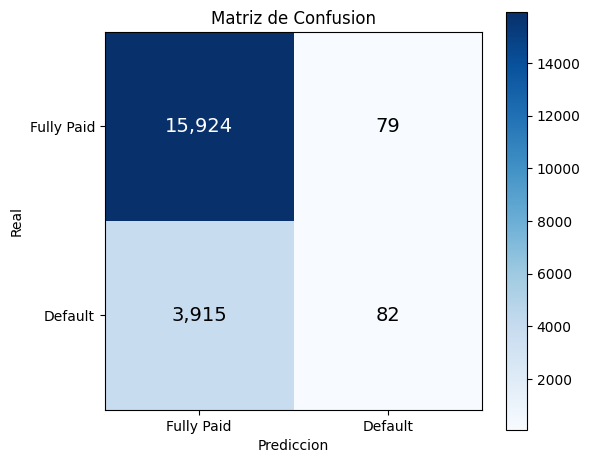


Verdaderos Negativos (TN): 15,924
Falsos Positivos (FP):     79
Falsos Negativos (FN):     3,915  <- Defaults no detectados
Verdaderos Positivos (TP): 82


In [22]:
# 7.3 - Matriz de Confusion
# Muestra los aciertos y errores del modelo en formato tabla:
#   - Verdaderos Negativos (TN): Fully Paid correctamente clasificados
#   - Falsos Positivos (FP): Fully Paid clasificados como Default (error tipo I)
#   - Falsos Negativos (FN): Default clasificados como Fully Paid (error tipo II) <- PELIGROSO en banca
#   - Verdaderos Positivos (TP): Default correctamente clasificados

cm = confusion_matrix(y_test_flat, class_predicted)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Fully Paid", "Default"])
ax.set_yticklabels(["Fully Paid", "Default"])
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusion")

# Anotar los valores en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN): {cm[0,0]:,}")
print(f"Falsos Positivos (FP):     {cm[0,1]:,}")
print(f"Falsos Negativos (FN):     {cm[1,0]:,}  <- Defaults no detectados")
print(f"Verdaderos Positivos (TP): {cm[1,1]:,}")

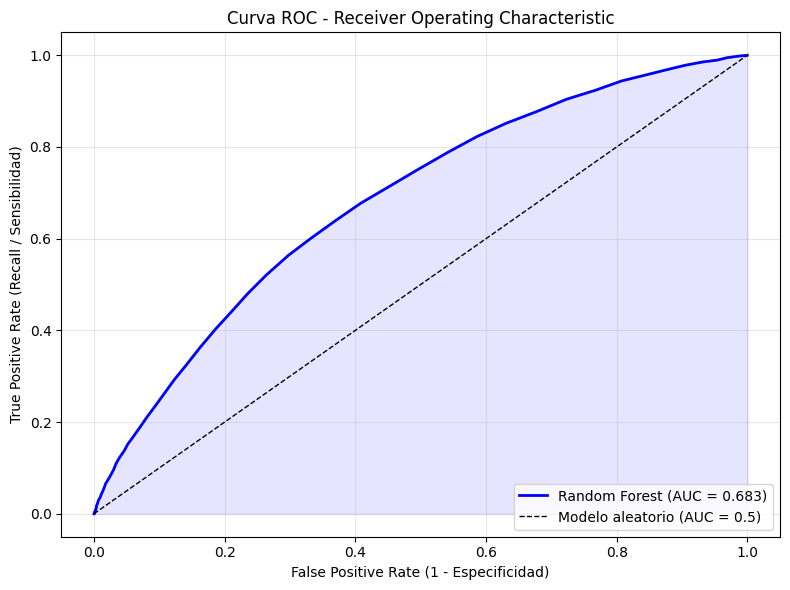


AUC-ROC: 0.6829


In [23]:
# 7.4 - Curva ROC y AUC
# La curva ROC representa la capacidad del modelo para distinguir entre clases
# a diferentes umbrales de decision:
#   - Eje X: False Positive Rate (FPR) = FP / (FP + TN)
#   - Eje Y: True Positive Rate (TPR) = TP / (TP + FN) = Recall
#
# AUC (Area Under the Curve):
#   - AUC = 1.0: modelo perfecto
#   - AUC = 0.5: modelo aleatorio (la diagonal)
#   - AUC > 0.7: modelo aceptable
#   - AUC > 0.8: buen modelo
#
# Usamos predict_proba (probabilidades) en vez de predict (clases) para calcular la curva ROC.

auc = roc_auc_score(y_test_flat, prob_predicted)
fpr, tpr, thresholds = roc_curve(y_test_flat, prob_predicted)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Modelo aleatorio (AUC = 0.5)")
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate (1 - Especificidad)')
plt.ylabel('True Positive Rate (Recall / Sensibilidad)')
plt.title('Curva ROC - Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC: {auc:.4f}")

In [24]:
# 7.5 - Resumen final de metricas
# Calculamos precision, recall y f1 para la clase positiva (Default = True)
precision = precision_score(y_test_flat, class_predicted)
recall = recall_score(y_test_flat, class_predicted)
f1 = f1_score(y_test_flat, class_predicted)

print("=" * 60)
print("RESUMEN FINAL DE METRICAS (clase positiva = Default)")
print("=" * 60)
print(f"  Accuracy:   {test_accuracy:.4f}  (proporcion total de aciertos)")
print(f"  Precision:  {precision:.4f}  (de los que predigo default, cuantos lo son)")
print(f"  Recall:     {recall:.4f}  (de los defaults reales, cuantos detecto)")
print(f"  F1-Score:   {f1:.4f}  (equilibrio entre precision y recall)")
print(f"  AUC-ROC:    {auc:.4f}  (capacidad de separar clases)")
print("=" * 60)
print()
print("INTERPRETACION:")
print(f"  - El modelo tiene un AUC de {auc:.3f}, lo que indica una capacidad")
print(f"    {'buena' if auc > 0.7 else 'limitada'} para distinguir entre defaults y fully paid.")
print(f"  - El recall de {recall:.3f} significa que detectamos el {recall*100:.1f}% de los defaults.")
print(f"  - En banca, un bajo recall es peligroso: prestamos aprobados que acabaran en default.")

RESUMEN FINAL DE METRICAS (clase positiva = Default)
  Accuracy:   0.8003  (proporcion total de aciertos)
  Precision:  0.5093  (de los que predigo default, cuantos lo son)
  Recall:     0.0205  (de los defaults reales, cuantos detecto)
  F1-Score:   0.0394  (equilibrio entre precision y recall)
  AUC-ROC:    0.6829  (capacidad de separar clases)

INTERPRETACION:
  - El modelo tiene un AUC de 0.683, lo que indica una capacidad
    limitada para distinguir entre defaults y fully paid.
  - El recall de 0.021 significa que detectamos el 2.1% de los defaults.
  - En banca, un bajo recall es peligroso: prestamos aprobados que acabaran en default.
